In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/hashes.txt
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv
/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/database.sqlite


# Data loading 

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv')

print('dataframe is loaded ')
print(df.shape)

df.head()

dataframe is loaded 
(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
missing_text = df['Text'].isnull().sum()
print(f"\nMissing values in 'Text' column: {missing_text}")


Missing values in 'Text' column: 0


# EDA and preprocessing .

<Axes: ylabel='Frequency'>

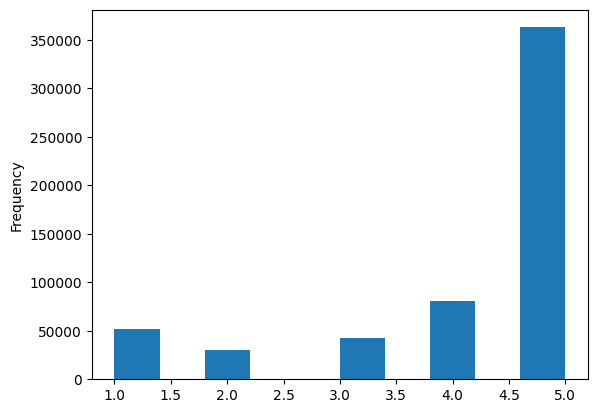

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Score'].plot(kind='hist')

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [6]:
def clean_text(text):

    text = str(text).lower()
    text = re.sub(r'<.*?>','',text)
    text = re.sub(r'[^a-zA-Z\s]','',text)
    
    words = text.split()
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return clean_words

df['clean_text'] = df['Text'].head(5000).apply(clean_text)

df['clean_text'].head()

0    [bought, several, vitality, canned, dog, food,...
1    [product, arrived, labeled, jumbo, salted, pea...
2    [confection, around, century, light, pillowy, ...
3    [looking, secret, ingredient, robitussin, beli...
4    [great, taffy, great, price, wide, assortment,...
Name: clean_text, dtype: object

In [7]:
sub_data = df.sample(50000)

In [8]:
sub_data['clean_text'] = sub_data['Text'].apply(clean_text)

In [9]:
sub_data.shape

(50000, 11)

In [10]:
sub_data.drop(columns=['UserId','Id','ProductId','ProfileName','HelpfulnessNumerator','HelpfulnessDenominator','Time'],inplace=True)

In [11]:
sub_data.drop(columns='Text',inplace=True)
sub_data.rename(columns={'Score':'Rating'},inplace=True)
sub_data

,Rating,Summary,clean_text
329798,5,Greenies Dental Chews,"[dog, year, old, bichon, frise, loving, greeni..."
302908,1,MJ,"[would, love, try, product, since, easy, find,..."
448897,5,Cheetos are out.,"[michael, season, baked, cheese, snack, dont, ..."
284265,4,Good..she ate it.,"[course, tasted, prior, giving, month, old, da..."
355453,3,Makes a good cup of coffee,"[tried, kcup, sampler, pack, fullbodied, taste..."
...,...,...,...
355210,5,Back to Nature California Lemon Cookies,"[wonderful, lemon, cooky, especially, like, te..."
475843,4,good choices,"[variety, pack, offer, choice, appeal, wide, v..."
486629,1,Pond water would taste better..,"[stale, tastless, crap, dont, bother, hassle, ..."
472912,5,"Dog with Allergies, Sensitive Stomach","[feeding, nature, variety, instinct, turkey, d..."


In [12]:
sub_data.isnull().sum()

Rating        0
Summary       2
clean_text    0
dtype: int64

In [13]:
sub_data.dropna(inplace=True)
sub_data.shape

(49998, 3)

In [14]:
from gensim.corpora import Dictionary

In [15]:
# 1. Create the Dictionary
# This maps every unique word to a unique ID
dictionary = Dictionary(df['clean_text'].dropna())
# 2. optional method maps only those with above 50% docs in all docs 
dictionary.filter_extremes(no_below=5, no_above=0.5)
# 3. creating the bag of words
corpus = [dictionary.doc2bow(text) for text in df['clean_text'].dropna()]

print(f"Number of unique tokens: {len(dictionary)}")
print(f"Number of documents in corpus: {len(corpus)}")

Number of unique tokens: 3299
Number of documents in corpus: 5000


In [16]:
from gensim.models import LdaModel

num_of_topic = 5

lda_model = LdaModel(
    corpus = corpus,
    id2word = dictionary,
    num_topics = num_of_topic,
    passes = 10,
    random_state = 42,
)

for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

Topic: 0 
Words: 0.019*"chip" + 0.019*"flavor" + 0.016*"like" + 0.016*"tea" + 0.015*"taste" + 0.013*"great" + 0.012*"love" + 0.011*"good" + 0.011*"bag" + 0.007*"snack"

Topic: 1 
Words: 0.036*"coffee" + 0.016*"mix" + 0.016*"taste" + 0.014*"pancake" + 0.013*"like" + 0.013*"make" + 0.012*"good" + 0.010*"gluten" + 0.009*"free" + 0.009*"product"

Topic: 2 
Words: 0.022*"product" + 0.011*"would" + 0.008*"one" + 0.008*"amazon" + 0.007*"time" + 0.007*"like" + 0.007*"price" + 0.006*"get" + 0.006*"box" + 0.006*"great"

Topic: 3 
Words: 0.017*"chocolate" + 0.016*"hot" + 0.014*"like" + 0.013*"taste" + 0.013*"good" + 0.011*"flavor" + 0.010*"water" + 0.010*"one" + 0.009*"add" + 0.009*"make"

Topic: 4 
Words: 0.053*"food" + 0.041*"dog" + 0.014*"love" + 0.013*"newman" + 0.011*"organic" + 0.011*"year" + 0.010*"eat" + 0.010*"one" + 0.009*"like" + 0.008*"old"



In [17]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model, 
    texts=df['clean_text'].dropna(), 
    dictionary=dictionary, 
    coherence='c_v'
)
print(f"Coherence Score: {coherence_model.get_coherence()}")

Coherence Score: 0.3999235786039391
